# 3.2 总结：DSSM、MIND 与 SASRec 召回

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

读取本章节每个独立算法 Notebook 的实际结果产物，在统一口径下比较和选型。

## Setup

本 Notebook 的默认真实数据是 **Amazon Reviews 2023 Video Games 5-core：电商召回与 Transformer 序列**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。

**主要资料：** DSSM · MIND · SASRec 原始论文

In [1]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.environ.setdefault("RECSYS_PROFILE", "smoke")
PROFILE = os.environ["RECSYS_PROFILE"]
from recsys_lab.data import (load_movielens, movielens_provenance, load_amazon_2023,
                             amazon_provenance, load_kuairand, kuairand_provenance)
DATASET_KEY = "amazon-2023"
if DATASET_KEY == "movielens":
    real_ratings, real_movies = load_movielens()
    real_interactions = real_ratings
    REAL_DATASET = movielens_provenance(real_ratings)
elif DATASET_KEY == "amazon-2023":
    real_ratings = load_amazon_2023()
    real_interactions, real_movies = real_ratings, None
    REAL_DATASET = amazon_provenance(real_ratings)
else:
    real_interactions, real_movies = load_kuairand()
    real_ratings = real_interactions
    REAL_DATASET = kuairand_provenance(real_interactions)
print({"profile": PROFILE, "root": str(ROOT), "real_dataset": REAL_DATASET})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

{'profile': 'smoke', 'root': '/workspace', 'real_dataset': {'dataset': 'Amazon Reviews 2023 / Video Games / 5-core', 'source': 'https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/benchmark/5core/rating_only/Video_Games.csv.gz', 'source_sha256': 'a2bde5f3b945960d161538c200dd87845e6ee471b46da96410dde61613c6901c', 'slice_rule': 'top 500 users by observed interaction count; ties by user_id; all their rows retained', 'rows_used': 18699, 'users_used': 160, 'items_used': 7942, 'time_min_utc': '1999-11-18T22:46:49+00:00', 'time_max_utc': '2023-05-31T16:03:41+00:00', 'positive_rule': 'observed Amazon rating >= 4.0', 'randomly_fabricated_rows': 0}}


## 开篇回顾

本章节固定为 **开篇导读 → 独立算法教程 → 结果总结**。每篇算法 Notebook 都包含论文、数学、数据、训练、推理、测试与讨论；本页不重新训练，也不手填数字。

DSSM 用单向量换取简单 ANN；MIND 用多向量覆盖并行意图；SASRec 用因果注意力刻画意图随顺序的变化。三者都可输出用户向量并接全库检索，Recall 必须与 Coverage、索引成本和序列延迟一起看。

## Results

读取 results 目录。若缺文件，请先按章节顺序执行算法 Notebook。

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
result_dir=ROOT/'results'/'chapter_3_2'; files=sorted(result_dir.glob('*.json'))
assert len(files)==3,f'期望 3 个结果，实际 {[p.name for p in files]}'
records=[]
for path in files: records.extend(json.loads(path.read_text(encoding='utf-8'))['records'])
comparison=pd.DataFrame(records); display(comparison.round(4)); print('数据来源:',[p.name for p in files])

,algorithm,primary_metric,primary_value,secondary_metric,secondary_value,baseline_metric,baseline_value,framework,source_notebook,dataset,randomly_fabricated_rows
0,DSSM 双塔召回,recall@10,0.0078,test_auc,0.5937,None,None,torch_rechub.models.matching.DSSM,3_2_1_dssm,Amazon Reviews 2023 / Video Games / 5-core,0
1,MIND 多兴趣召回,recall@10,0.0000,positive_top1,0.8516,None,None,torch_rechub.models.matching.MIND,3_2_2_mind,Amazon Reviews 2023 / Video Games / 5-core,0
2,SASRec 序列召回,hr@10,0.0191,popularity_hr@10,0.0064,None,None,torch_rechub.models.matching.SASRec,3_2_3_sasrec,Amazon Reviews 2023 / Video Games / 5-core,0


数据来源: ['3_2_1_dssm.json', '3_2_2_mind.json', '3_2_3_sasrec.json']


/tmp/ipykernel_1387/253447002.py:6: UserWarning: Glyph 21452 (\N{CJK UNIFIED IDEOGRAPH-53CC}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1387/253447002.py:6: UserWarning: Glyph 22612 (\N{CJK UNIFIED IDEOGRAPH-5854}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1387/253447002.py:6: UserWarning: Glyph 21484 (\N{CJK UNIFIED IDEOGRAPH-53EC}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1387/253447002.py:6: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1387/253447002.py:6: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1387/253447002.py:6: UserWarning: Glyph 20852 (\N{CJK UNIFIED IDEOGRAPH-5174}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1387/253447002.py:6

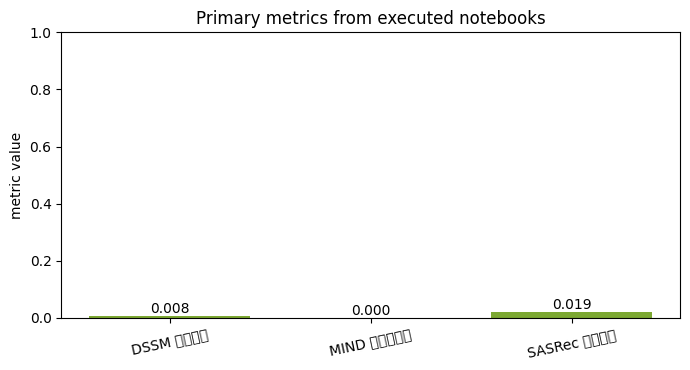

In [3]:
fig,ax=plt.subplots(figsize=(max(7,len(comparison)*1.5),3.8))
bars=ax.bar(comparison.algorithm,comparison.primary_value,color='#7ca832')
ax.set(title='Primary metrics from executed notebooks',ylabel='metric value',ylim=(0,max(1.0,comparison.primary_value.max()*1.18)))
ax.tick_params(axis='x',rotation=12)
for bar,value in zip(bars,comparison.primary_value): ax.text(bar.get_x()+bar.get_width()/2,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show()

## Takeaways

DSSM 用单向量换取简单 ANN；MIND 用多向量覆盖并行意图；SASRec 用因果注意力刻画意图随顺序的变化。三者都可输出用户向量并接全库检索，Recall 必须与 Coverage、索引成本和序列延迟一起看。

先固定业务阶段和候选口径，再比较主指标、辅助指标、baseline 与系统成本。smoke 数值用于代码回归和学习，不能跨数据或跨公司宣称优劣。

## Checks

In [4]:
assert len(comparison)==3
assert comparison.source_notebook.nunique()==3
assert comparison.primary_value.between(0,1).all()
print('PASS：总结完全来自独立 Notebook 的执行产物。')

PASS：总结完全来自独立 Notebook 的执行产物。


## Next Steps

在相同完整数据、时间切分、负样本和候选集上重跑；加入效果—延迟—成本三维表，再决定是否进入线上 A/B。